In [ ]:
library(data.table)
install.packages('caret')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’




In [ ]:
install.packages('dplyr')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(caret)
library(dplyr)

Loading required package: ggplot2

Loading required package: lattice


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
df <- fread('/content/final_data.csv')

In [ ]:
df$V1 <- NULL
df$age <- NULL

Warning message in set(x, j = name, value = value):
“Tried to assign NULL to column 'V1', but this column does not exist to remove”


In [ ]:
str(df)

Classes ‘data.table’ and 'data.frame':	383906 obs. of  16 variables:
 $ temperature   : num  98.8 97.1 98.6 99.4 98.1 98.9 97.8 97.8 99.6 98.1 ...
 $ heartrate     : num  96 54 85 85 60 85 106 93 100 78 ...
 $ resprate      : int  18 18 16 16 18 18 18 18 16 16 ...
 $ o2sat         : num  93 95 98 100 94 100 100 93 96 100 ...
 $ sbp           : num  160 143 189 148 120 123 190 140 146 127 ...
 $ dbp           : int  54 73 96 86 95 75 112 70 96 78 ...
 $ gender        : chr  "F" "F" "M" "F" ...
 $ race          : chr  "White" "White" "White" "Other" ...
 $ icd_category  : Factor w/ 20 levels "Blood","Circulatory",..: 4 12 9 13 17 17 5 9 10 17 ...
 $ outcome       : Factor w/ 2 levels "0","1": 2 2 2 1 1 1 2 1 1 1 ...
 $ temperature_mi: int  0 0 0 0 0 0 0 0 0 0 ...
 $ heartrate_mi  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ resprate_mi   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ sbp_mi        : int  0 0 0 0 0 0 0 0 0 0 ...
 $ dbp_mi        : int  0 0 0 1 0 0 0 0 0 0 ...
 $ o2sat_mi      : int  0 0 0 0 0 0 

In [ ]:
df$icd_category   <- factor(df$icd_category)
df$outcome <- factor(df$outcome)

In [ ]:
set.seed(123)

idx_train <- createDataPartition(y = df$outcome,
                                 p = 0.9,
                                 list = FALSE)

train_df <- df[idx_train, ]
test_df  <- df[-idx_train, ]

In [ ]:
fit_logit <- glm(
  outcome ~. ,
  data   = train_df,
  family = binomial
  )

In [ ]:
fit_logit_step <- step(fit_logit, direction = "backward")

Start:  AIC=407725.2
outcome ~ temperature + heartrate + resprate + o2sat + sbp + 
    dbp + gender + race + icd_category + temperature_mi + heartrate_mi + 
    resprate_mi + sbp_mi + dbp_mi + o2sat_mi


Step:  AIC=407725.2
outcome ~ temperature + heartrate + resprate + o2sat + sbp + 
    dbp + gender + race + icd_category + temperature_mi + heartrate_mi + 
    resprate_mi + sbp_mi + dbp_mi

                 Df Deviance    AIC
<none>                407653 407725
- heartrate_mi    1   407657 407727
- dbp_mi          1   407659 407729
- sbp_mi          1   407701 407771
- resprate_mi     1   407722 407792
- temperature_mi  1   407798 407868
- sbp             1   408018 408088
- gender          1   408062 408132
- heartrate       1   408401 408471
- temperature     1   408580 408650
- dbp             1   411588 411658
- resprate        1   411598 411668
- race            4   412778 412842
- o2sat           1   417727 417797
- icd_category   19   421973 422007


In [ ]:
summary(fit_logit_step)


Call:
glm(formula = outcome ~ temperature + heartrate + resprate + 
    o2sat + sbp + dbp + gender + race + icd_category + temperature_mi + 
    heartrate_mi + resprate_mi + sbp_mi + dbp_mi, family = binomial, 
    data = train_df)

Coefficients:
                                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)                       7.0818858  0.4531380  15.629  < 2e-16 ***
temperature                       0.1222309  0.0040394  30.260  < 2e-16 ***
heartrate                         0.0062322  0.0002281  27.320  < 2e-16 ***
resprate                          0.1112703  0.0018242  60.996  < 2e-16 ***
o2sat                            -0.2000988  0.0020687 -96.727  < 2e-16 ***
sbp                               0.0037547  0.0001963  19.125  < 2e-16 ***
dbp                              -0.0192216  0.0003095 -62.103  < 2e-16 ***
genderM                           0.1557449  0.0077053  20.213  < 2e-16 ***
raceBlack                        -0.0577287  0.0204045  -2.829  0.00

In [ ]:
predict_value <- predict(fit_logit_step, newdata = test_df, type = "response") %>% tibble(predict_value =.)

predict_value %>% show()

# A tibble: 38,390 × 1
   predict_value
           <dbl>
 1         0.372
 2         0.366
 3         0.582
 4         0.239
 5         0.197
 6         0.332
 7         0.538
 8         0.535
 9         0.580
10         0.376
# ℹ 38,380 more rows


In [ ]:
real_predict <- test_df %>% select(outcome) %>% dplyr::bind_cols(.,predict_value)

head(real_predict,5)

outcome,predict_value
<fct>,<dbl>
0,0.3721796
0,0.3664836
0,0.5820811
1,0.2390546
0,0.1973664


Setting levels: control = 0, case = 1

Setting direction: controls < cases



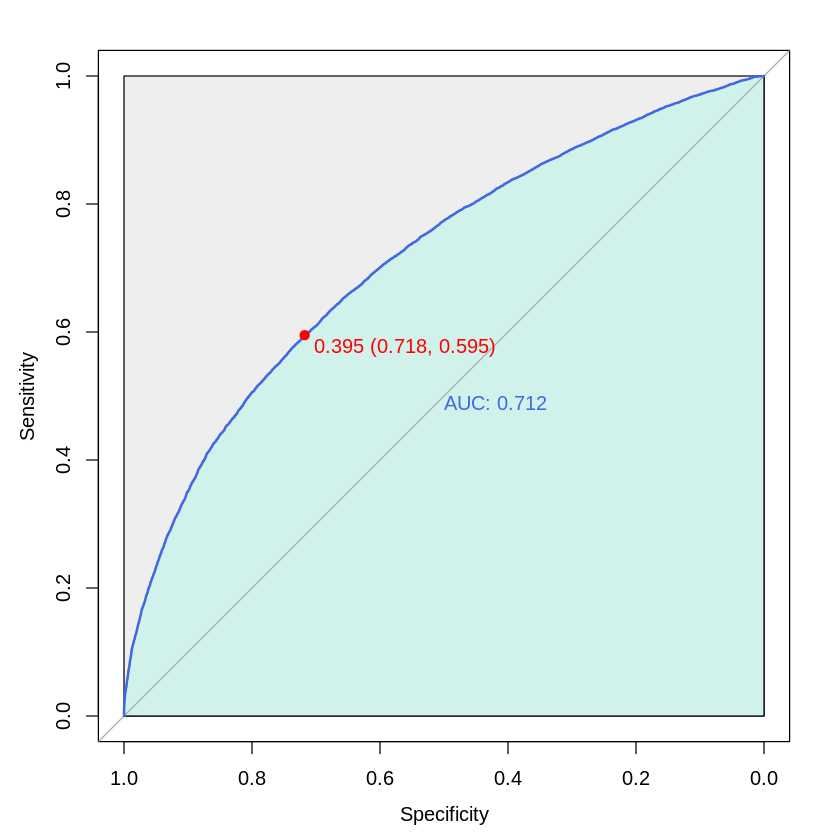

In [ ]:
roc_cutoff <- pROC::roc(real_predict$outcome, real_predict$predict_value)
pROC::plot.roc(roc_cutoff,
  col="royalblue",
  print.auc=TRUE,
  max.auc.polygon=TRUE,
  print.thres=TRUE, print.thres.pch=19, print.thres.col = "red",
  auc.polygon=TRUE, auc.polygon.col="#D1F2EB")

In [ ]:
roc_cutoff_value <- pROC::coords(roc_cutoff, "best", ret = "threshold", transpose = F)[1,1]
roc_cutoff_value

[1] 0.3950194

In [ ]:
real_predict <- real_predict %>%
mutate(predict_survival_roccut = as.factor(ifelse(predict_value > roc_cutoff_value, "1", "0")))

In [ ]:
head(real_predict, 5)

outcome,predict_value,predict_survival_roccut
<fct>,<dbl>,<fct>
0,0.3721796,0
0,0.3664836,0
0,0.5820811,1
1,0.2390546,0
0,0.1973664,0


In [ ]:
str(real_predict)

Classes ‘data.table’ and 'data.frame':	38390 obs. of  3 variables:
 $ outcome                : Factor w/ 2 levels "0","1": 1 1 1 2 1 2 1 2 2 1 ...
 $ predict_value          : num  0.372 0.366 0.582 0.239 0.197 ...
 $ predict_survival_roccut: Factor w/ 2 levels "0","1": 1 1 2 1 1 1 2 2 2 1 ...
 - attr(*, ".internal.selfref")=<externalptr> 


In [ ]:
caret::confusionMatrix(real_predict$outcome,real_predict$predict_survival_roccut, positive = "1")

Confusion Matrix and Statistics

          Reference
Prediction     0     1
         0 17067  6712
         1  5917  8694
                                          
               Accuracy : 0.671           
                 95% CI : (0.6663, 0.6757)
    No Information Rate : 0.5987          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.3095          
                                          
 Mcnemar's Test P-Value : 1.602e-12       
                                          
            Sensitivity : 0.5643          
            Specificity : 0.7426          
         Pos Pred Value : 0.5950          
         Neg Pred Value : 0.7177          
             Prevalence : 0.4013          
         Detection Rate : 0.2265          
   Detection Prevalence : 0.3806          
      Balanced Accuracy : 0.6534          
                                          
       'Positive' Class : 1               
                  

In [ ]:
install.packages('rmda')

In [ ]:
library(rmda)

In [ ]:
# test_data$outcome은 factor이므로 numeric으로 변환
eval_data <- data.frame(
  outcome = as.numeric(as.character(test_df$outcome)),
  # pred_probs는 이미 1(입원)일 확률입니다.
  risk_score = real_predict$predict_survival_roccut
)

In [ ]:
names(eval_data)
str(eval_data)

[1] "outcome"    "risk_score"

'data.frame':	38390 obs. of  2 variables:
 $ outcome   : num  0 0 0 1 0 1 0 1 1 0 ...
 $ risk_score: Factor w/ 2 levels "0","1": 1 1 2 1 1 2 2 2 2 1 ...


Warning message in quartz(width = 10, height = 10):
“Quartz device is not available on this platform”


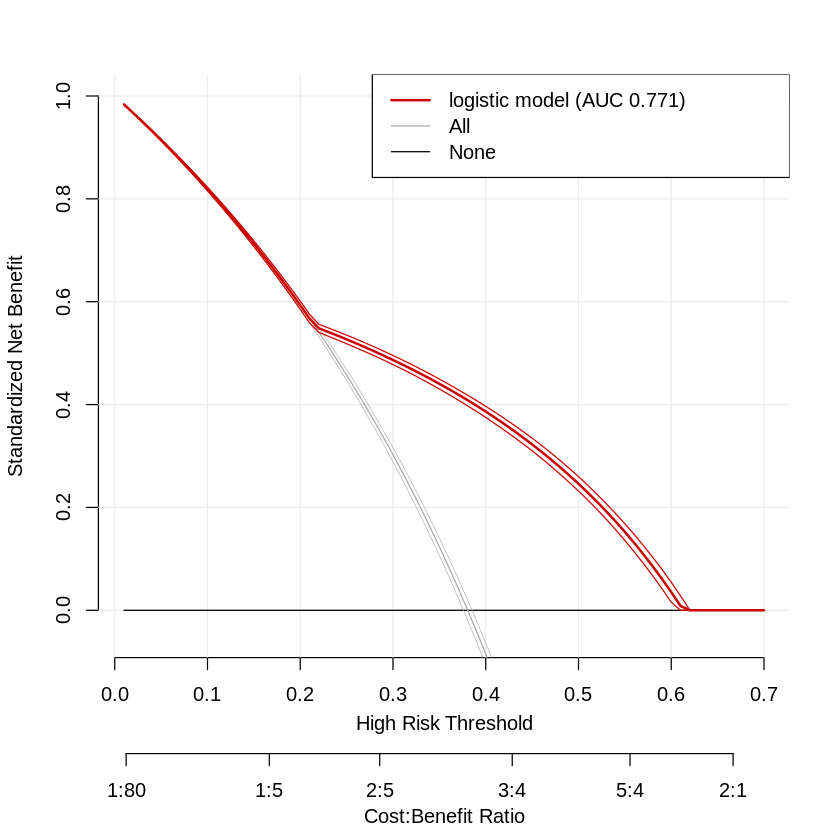

In [ ]:
# 3. Decision Curve Analysis 실행
# decision_curve(결과_변수 ~ 확률_변수)
# thresholds: 1%부터 60%까지 임계 확률을 테스트합니다. (의사가 보통 이 범위에서 고민함)
dca_result <- decision_curve(
  outcome ~ risk_score,
  data = eval_data,
  family = binomial(link = "logit"),
  thresholds = seq(0.01, 0.70, by = 0.01)
)

# 1. 새 창 띄우기 (윈도우 사용자라면 windows(), 맥은 quartz())
quartz(width = 10, height = 10)

plot_decision_curve(
  dca_result,
  curve.names = "logistic model (AUC 0.771)",
  cost.benefit.axis = TRUE,
  legend.position = "topright"
)


In [ ]:
cm <- confusionMatrix(
  data      = factor(real_predict$predict_survival_roccut, levels = c(0, 1)),
  reference = factor(real_predict$outcome,                levels = c(0, 1)),
  positive  = "1"   # ← 양성 클래스 지정
)

cm
cm$byClass["F1"]   # F1-score (positive = 1)

In [ ]:
fit <- glm(outcome ~ ., data = train_df, family = binomial)

library(broom)
library(ggplot2)

coef_df |>
  dplyr::filter(term != "(Intercept)") |>
  ggplot(aes(x = estimate, y = term)) +
  geom_point() +
  geom_errorbar(
    aes(xmin = conf.low, xmax = conf.high),
    width = 0,              # 세로방향 에러바일 때는 width
    orientation = "y"       # 수평 에러바처럼 동작
  ) +
  geom_vline(xintercept = 1, linetype = "dashed") +
  scale_x_log10() +
  labs(x = "Odds ratio (log scale)", y = NULL)



ERROR: Error: object 'coef_df' not found


In [ ]:
install.packages('iml')

In [ ]:
library(iml)

predict_fun <- function(model, newdata) {
  predict(model, newdata, type = "response")
}

X <- train_data[ , setdiff(names(train_data), "outcome")]
y <- train_data$outcome

predictor <- Predictor$new(
  model = fit,
  data  = X,
  y     = y,
  predict.function = predict_fun
)

# 예: anchor_age에 대한 partial dependence
pdp_age <- FeatureEffect$new(predictor, feature = "anchor_age", method = "pdp")
plot(pdp_age)


In [ ]:
install.packages('corrplot')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(corrplot)

corrplot 0.95 loaded



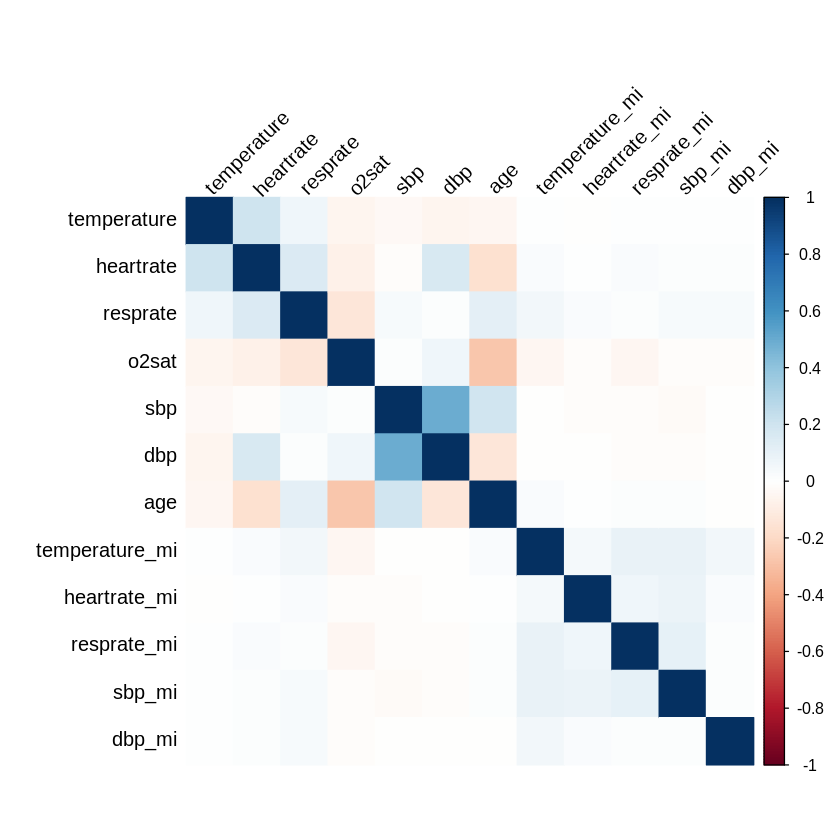

In [ ]:
setDT(df)

vars <- c("temperature","heartrate","resprate","o2sat",
          "sbp","dbp","age",
          "temperature_mi","heartrate_mi","resprate_mi",
          "sbp_mi","dbp_mi")

num_df <- df[ , ..vars]

cor_mat <- cor(num_df, use = "complete.obs")
corrplot(cor_mat, method = "color", type = "full",
         tl.col = "black", tl.srt = 45)

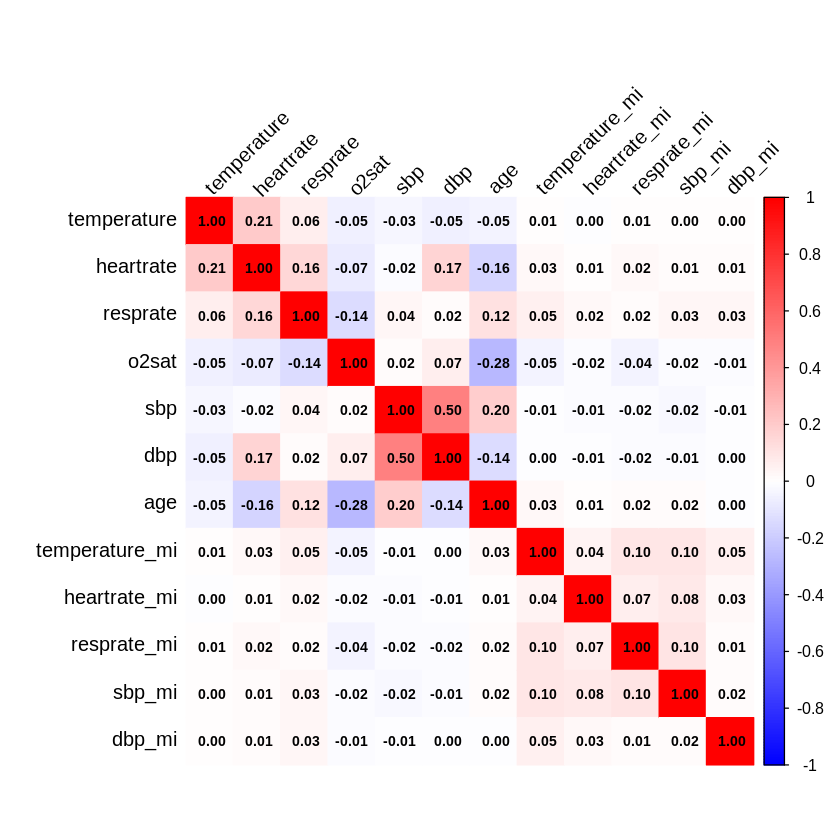

In [ ]:
library(data.table)
library(corrplot)

# 데이터가 df에 있다고 가정
setDT(df)

# 분석할 변수 목록 (outcome 포함, _mi 변수 포함 여부는 선택)
vars <- c("temperature","heartrate","resprate","o2sat",
          "sbp","dbp","age",
          "temperature_mi","heartrate_mi","resprate_mi",
          "sbp_mi","dbp_mi")
# 만약 outcome도 보고 싶으시면 위 리스트에 "outcome"을 추가하세요.

# 1. 데이터 추출
num_df <- df[, ..vars]

# 2. [핵심 수정] 모든 컬럼을 숫자로 강제 변환 (에러 방지)
# 문자로 된 숫자가 있다면 숫자로 바뀌고, 진짜 문자는 NA가 됩니다.
num_df <- num_df[, lapply(.SD, as.numeric)]

# 3. 상관계수 계산
cor_mat <- cor(num_df, use = "complete.obs")

# 4. 그래프 그리기
corrplot(cor_mat,
         method = "color",
         type = "full",
         tl.col = "black",
         tl.srt = 45,
         addCoef.col = "black", # 상관계수 숫자 표시
         number.cex = 0.7,      # 숫자 크기 조절
         col = colorRampPalette(c("blue", "white", "red"))(200)
)